---
title: "SSH 2: Chiral Symmetry and Winding"
subtitle: "How a Bloch Hamiltonian Encircles the Origin"
artifact_status: "Exploratory beginner notebook; not canonical or supported"
---

# SSH 2: Chiral Symmetry and Winding

Notebook 1 introduced

$$
H(k)=\begin{pmatrix}0&t_1+t_2e^{-ik}\\t_1+t_2e^{ik}&0\end{pmatrix}.
$$

This notebook rewrites that matrix as a two-component vector, checks chiral symmetry, and visualizes a winding number. We retain the same unit-cell convention, positive real hoppings, and zero onsite energies.

## Learning objectives

After this notebook, you should be able to identify the chiral symmetry operator, draw the Bloch $d$-vector path, compute its winding in the gapped cases, and explain why the winding can change only when the path crosses the origin and the energy gap closes.

As in notebook 1, deterministic comparisons use the task-local absolute tolerance $10^{-10}$ with relative tolerance set to zero; no universal tolerance is implied.


## 1. From a matrix to a planar vector

Using Pauli matrices,

$$
H(k)=d_x(k)\sigma_x+d_y(k)\sigma_y,
$$

with

$$
d_x(k)=t_1+t_2\cos k,\qquad d_y(k)=t_2\sin k.
$$

As $k$ runs through the Brillouin zone, $(d_x,d_y)$ traces a circle of radius $t_2$ centered at $(t_1,0)$.


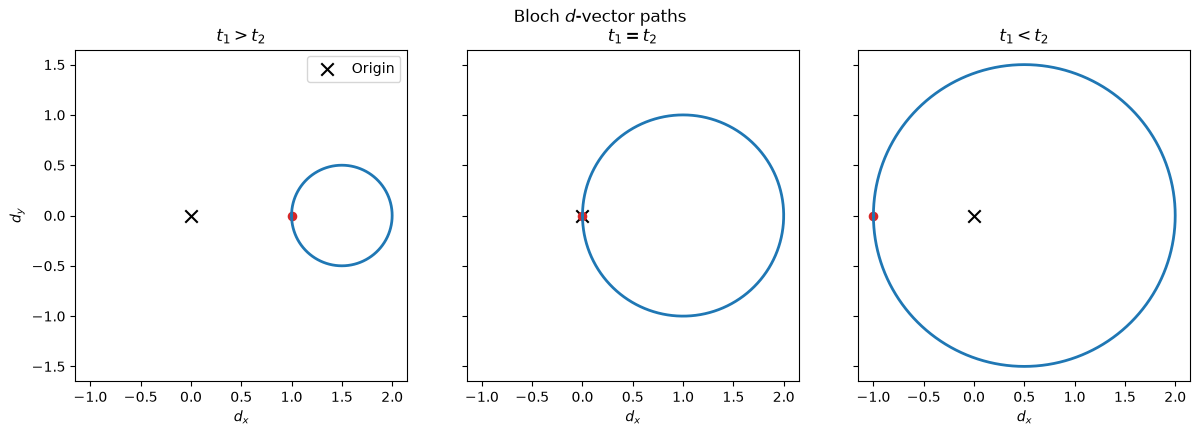

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose

ATOL = 1.0e-10
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)


def d_vector(k, t1, t2):
    return t1 + t2 * np.cos(k), t2 * np.sin(k)


def ssh_bloch_hamiltonian(k, t1, t2):
    dx, dy = d_vector(k, t1, t2)
    return dx * sigma_x + dy * sigma_y

k_closed = np.linspace(-np.pi, np.pi, 801)
cases = [(1.5, 0.5, "$t_1>t_2$"), (1.0, 1.0, "$t_1=t_2$"), (0.5, 1.5, "$t_1<t_2$")]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), sharex=True, sharey=True)
for ax, (t1, t2, title) in zip(axes, cases):
    dx, dy = d_vector(k_closed, t1, t2)
    ax.plot(dx, dy, linewidth=2)
    ax.scatter([0], [0], marker="x", s=80, color="black", label="Origin")
    ax.scatter([dx[0]], [dy[0]], s=35, color="tab:red")
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("$d_x$")
axes[0].set_ylabel("$d_y$")
axes[0].legend()
fig.suptitle("Bloch $d$-vector paths")
fig.tight_layout()
plt.show()


### Interpretation

The intracell-strong circle does not contain the origin, the critical circle passes through it, and the intercell-strong circle encloses it. Because the band energies are $E_\pm=\pm\sqrt{d_x^2+d_y^2}$, touching the origin is exactly the zero-gap condition.


## 2. Chiral symmetry

The sublattice operator is $\Gamma=\sigma_z$: it gives opposite signs to amplitudes on $A$ and $B$. With zero onsite terms,

$$
\Gamma H(k)\Gamma^{-1}=-H(k),
$$

or equivalently $\{\Gamma,H(k)\}=0$. This symmetry forces nonzero energies to occur in $\pm E$ pairs.


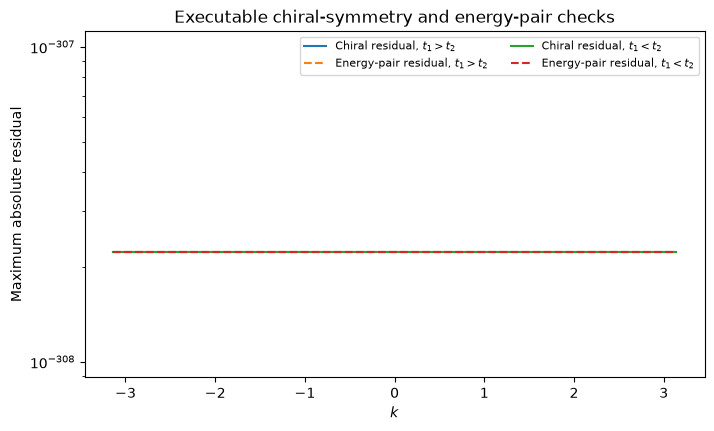

In [2]:
k_samples = np.linspace(-np.pi, np.pi, 121)
fig, ax = plt.subplots(figsize=(8, 4.5))
for t1, t2, label in [(1.5, 0.5, "$t_1>t_2$"), (0.5, 1.5, "$t_1<t_2$")]:
    residuals = []
    pairing_residuals = []
    for k in k_samples:
        H = ssh_bloch_hamiltonian(k, t1, t2)
        residuals.append(np.max(np.abs(sigma_z @ H + H @ sigma_z)))
        energies = np.linalg.eigvalsh(H)
        pairing_residuals.append(abs(energies[0] + energies[1]))
    residuals = np.array(residuals)
    pairing_residuals = np.array(pairing_residuals)
    assert np.max(residuals) < ATOL
    assert np.max(pairing_residuals) < ATOL
    ax.semilogy(k_samples, np.maximum(residuals, np.finfo(float).tiny), label=f"Chiral residual, {label}")
    ax.semilogy(k_samples, np.maximum(pairing_residuals, np.finfo(float).tiny), "--", label=f"Energy-pair residual, {label}")
ax.set_xlabel("$k$")
ax.set_ylabel("Maximum absolute residual")
ax.set_title("Executable chiral-symmetry and energy-pair checks")
ax.legend(ncol=2, fontsize=8)
plt.show()


### Interpretation

The plotted residuals are the same quantities constrained by the assertions. Their floating-point-scale values verify chiral anticommutation and $\pm E$ pairing for the sampled matrices. This is mathematical/software consistency for the finite calculation, not physical validation of a material.


## 3. Winding number in the gapped cases

When the path never touches the origin, define its continuous polar angle

$$
\theta(k)=\arg\bigl(d_x(k)+id_y(k)\bigr).
$$

The winding number under our orientation convention is

$$
\nu=\frac{\theta(\pi)-\theta(-\pi)}{2\pi}.
$$

The angle cannot be defined continuously at the critical point because the vector becomes zero.


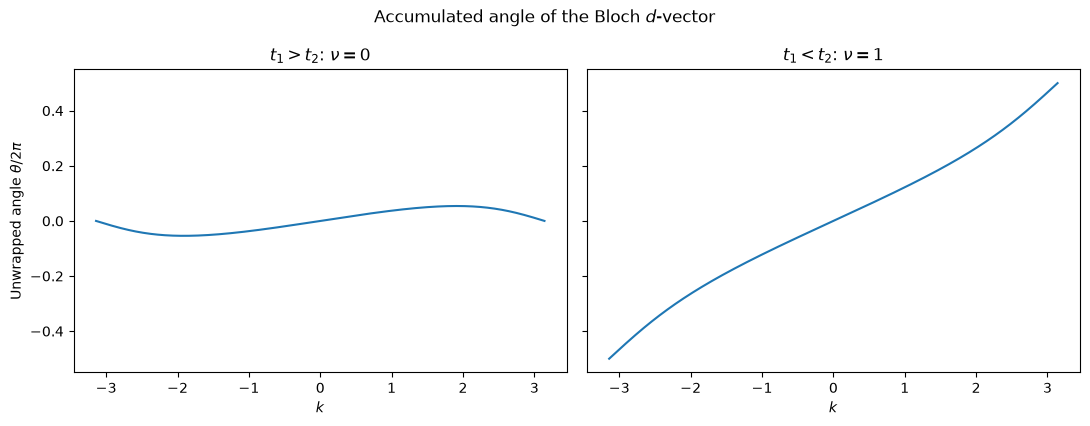

In [3]:
def winding_data(t1, t2):
    dx, dy = d_vector(k_closed, t1, t2)
    radius = np.hypot(dx, dy)
    if np.min(radius) < ATOL:
        raise ValueError("Winding is undefined when the d-vector crosses the origin.")
    angle = np.unwrap(np.angle(dx + 1j * dy))
    winding = (angle[-1] - angle[0]) / (2.0 * np.pi)
    return angle, winding

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (t1, t2, expected, title) in zip(
    axes,
    [(1.5, 0.5, 0.0, "$t_1>t_2$"), (0.5, 1.5, 1.0, "$t_1<t_2$")],
):
    angle, winding = winding_data(t1, t2)
    assert_allclose(winding, expected, atol=ATOL, rtol=0.0)
    ax.plot(k_closed, angle / (2 * np.pi))
    ax.set_title(f"{title}: $\\nu={winding:.0f}$")
    ax.set_xlabel("$k$")
axes[0].set_ylabel("Unwrapped angle $\\theta/2\\pi$")
fig.suptitle("Accumulated angle of the Bloch $d$-vector")
fig.tight_layout()
plt.show()


### Interpretation

The angle returns without a net turn when the circle misses the origin, giving $\nu=0$. It accumulates one full turn when the circle encloses the origin, giving $\nu=1$ under the chosen orientation. The sign and numerical label depend on orientation and unit-cell conventions; the convention is therefore part of the statement.


## 4. Why the invariant changes at a gap closing

We vary $t_1/t_2$ while keeping $t_2=1$. Away from equality, the circle either encloses or misses the origin. At equality the circle crosses the origin, so the winding formula is undefined and the gap is zero.


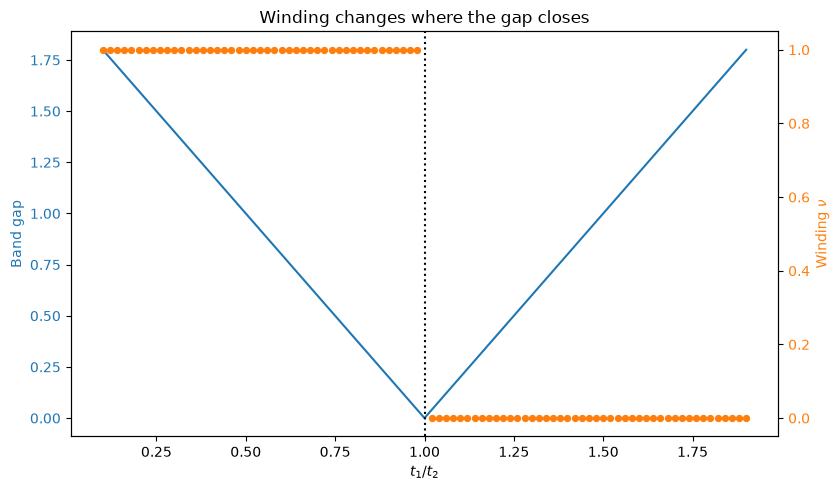

In [4]:
t2_fixed = 1.0
ratios_left = np.linspace(0.1, 0.98, 45)
ratios_right = np.linspace(1.02, 1.9, 45)
ratios = np.concatenate([ratios_left, ratios_right])
windings = []
for ratio in ratios:
    _, value = winding_data(ratio * t2_fixed, t2_fixed)
    windings.append(value)
windings = np.array(windings)
expected = np.where(ratios < 1.0, 1.0, 0.0)
assert_allclose(windings, expected, atol=ATOL, rtol=0.0)

gap_ratios = np.linspace(0.1, 1.9, 181)
gaps = 2.0 * np.abs(gap_ratios - 1.0)
fig, ax_gap = plt.subplots(figsize=(8.5, 5))
ax_gap.plot(gap_ratios, gaps, color="tab:blue", label="Band gap")
ax_gap.set_xlabel("$t_1/t_2$")
ax_gap.set_ylabel("Band gap", color="tab:blue")
ax_gap.tick_params(axis="y", labelcolor="tab:blue")
ax_w = ax_gap.twinx()
ax_w.scatter(ratios, windings, color="tab:orange", s=18, label="Winding")
ax_w.set_ylabel("Winding $\\nu$", color="tab:orange")
ax_w.tick_params(axis="y", labelcolor="tab:orange")
ax_gap.axvline(1.0, color="black", linestyle=":")
ax_gap.set_title("Winding changes where the gap closes")
fig.tight_layout()
plt.show()


### Interpretation

The winding is constant within each gapped region and is deliberately not evaluated at $t_1=t_2$. The only connection between the two integer values passes through the zero-gap point. This is the elementary topological distinction for the accepted SSH convention; notebook 3 tests how it appears at a particular open boundary.


## Summary and convention boundary

Chiral symmetry keeps the Bloch vector in the $(d_x,d_y)$ plane and pairs energies about zero. The vector winds around the origin only for $t_1<t_2$ under our cell and orientation convention. Its winding cannot change while the path stays away from the origin. A different unit-cell labeling or momentum orientation can change the numerical winding label, so bulk statements must be paired with explicit boundary conventions.
